# Car Reviews NLP - Complete Pipeline
## Análisis de Datos No Estructurados
### Raúl Jimeno, Ruben Navarro

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load API key
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# General configuration
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 100)

print(f"GROQ API key loaded: {'Yes' if GROQ_API_KEY else 'Not found'}")

GROQ API key loaded: Yes


In [13]:
from datasets import load_dataset

# Load only 2000 rows for quick exploration
dataset = load_dataset("florentgbelidji/car-reviews", split="train")
df = dataset.to_pandas()

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst rows:")
df.head()

Shape: (36984, 8)

Columns: ['Unnamed: 0.1', 'Unnamed: 0', 'Review_Date', 'Author_Name', 'Vehicle_Title', 'Review_Title', 'Review', 'Rating']

First rows:


,Unnamed: 0.1,Unnamed: 0,Review_Date,Author_Name,Vehicle_Title,Review_Title,Review,Rating
0,0,0,on 02/02/17 19:53 PM (PST),Ricardo,1997 Toyota Previa Minivan LE 3dr Minivan,"great vehicle, Toyota best design ever. thank you","there is no way back, enjoy what you have .",5
1,1,1,on 12/17/16 16:40 PM (PST),matt,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,"my 4th previa, best van ever made!",1st 95 went over 300k before being totalled by a truck running a red light. Walked away with no...,5
2,2,2,on 04/14/10 07:43 AM (PDT),Joel G,1997 Toyota Previa Minivan LE 3dr Minivan,Mom's Taxi Babies Ride,Sold 86 Toyota Van 285K miles to be replaced with 97 Previa with 1st baby coming in Jun. Perfec...,5
3,3,3,on 11/12/08 17:31 PM (PST),Dennis,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,My Favorite Van Ever,"I have owned lots of vans, and the Previa is far and away the best van I have ever owned. Buil...",5
4,4,4,on 04/14/08 22:47 PM (PDT),Alf Skrastins,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,Best Minivan ever,My 1997 AWD Previa is the third one that I have owned. I previously had a 1991 and a 1994. All ...,5


## 1. Exploratory Data Analysis (EDA)
### 1.1 Data Overview & Cleaning

In [14]:
# Basic dataset info
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Rating distribution ===")
print(df["Rating"].value_counts().sort_index())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 36984 entries, 0 to 36983
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0.1   36984 non-null  int64
 1   Unnamed: 0     36984 non-null  int64
 2   Review_Date    36984 non-null  str  
 3   Author_Name    36984 non-null  str  
 4   Vehicle_Title  36984 non-null  str  
 5   Review_Title   36980 non-null  str  
 6   Review         36984 non-null  str  
 7   Rating         36984 non-null  int64
dtypes: int64(3), str(5)
memory usage: 24.7 MB
None

=== Missing values ===
Unnamed: 0.1     0
Unnamed: 0       0
Review_Date      0
Author_Name      0
Vehicle_Title    0
Review_Title     4
Review           0
Rating           0
dtype: int64

=== Rating distribution ===
Rating
1      742
2     1511
3     2874
4    10194
5    21663
Name: count, dtype: int64


>- Only 4 missing values found in `Review_Title`, which is negligible and will not impact the analysis.

In [15]:
# Drop unnecessary columns and duplicates
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

# Drop rows with missing Review or Rating
df = df.dropna(subset=["Review", "Rating"])

# Convert Rating to integer
df["Rating"] = df["Rating"].astype(int)

# Remove duplicate reviews
df = df.drop_duplicates(subset=["Review"])

print(f"Clean dataset shape: {df.shape}")
df.head()

Clean dataset shape: (36629, 6)


,Review_Date,Author_Name,Vehicle_Title,Review_Title,Review,Rating
0,on 02/02/17 19:53 PM (PST),Ricardo,1997 Toyota Previa Minivan LE 3dr Minivan,"great vehicle, Toyota best design ever. thank you","there is no way back, enjoy what you have .",5
1,on 12/17/16 16:40 PM (PST),matt,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,"my 4th previa, best van ever made!",1st 95 went over 300k before being totalled by a truck running a red light. Walked away with no...,5
2,on 04/14/10 07:43 AM (PDT),Joel G,1997 Toyota Previa Minivan LE 3dr Minivan,Mom's Taxi Babies Ride,Sold 86 Toyota Van 285K miles to be replaced with 97 Previa with 1st baby coming in Jun. Perfec...,5
3,on 11/12/08 17:31 PM (PST),Dennis,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,My Favorite Van Ever,"I have owned lots of vans, and the Previa is far and away the best van I have ever owned. Buil...",5
4,on 04/14/08 22:47 PM (PDT),Alf Skrastins,1997 Toyota Previa Minivan LE All-Trac 3dr Minivan AWD,Best Minivan ever,My 1997 AWD Previa is the third one that I have owned. I previously had a 1991 and a 1994. All ...,5


=== Sentiment distribution ===
Sentiment
Positive    31523
Neutral      2865
Negative     2241
Name: count, dtype: int64


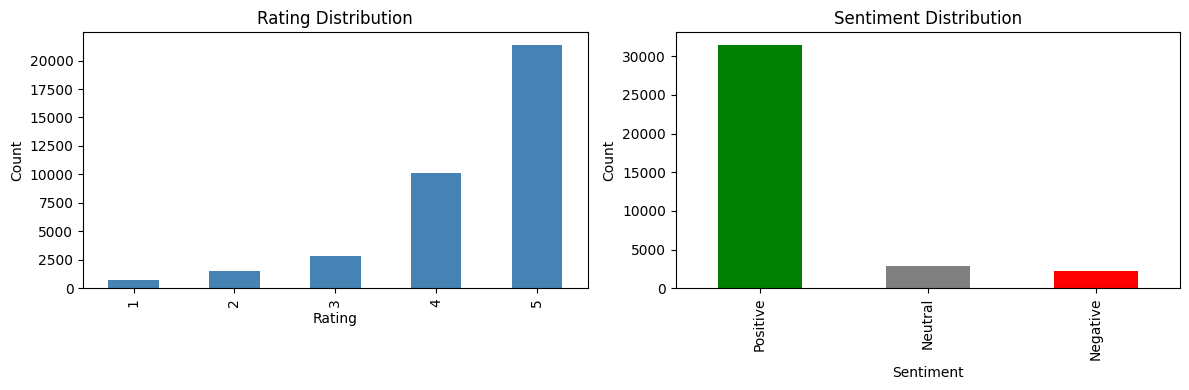

In [16]:
# Create sentiment labels from Rating
# 1-2 -> Negative, 3 -> Neutral, 4-5 -> Positive
def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(rating_to_sentiment)

print("=== Sentiment distribution ===")
print(df["Sentiment"].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
df["Rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Sentiment distribution
df["Sentiment"].value_counts().plot(kind="bar", ax=axes[1], color=["green", "gray", "red"])
axes[1].set_title("Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

>- The dataset reflects real-world review bias: people are more likely to write a review when they love a car than when they feel indifferent. This is known as "positivity bias" in user-generated content.

### 1.2 Text Analysis

=== Review length stats ===
count    36629.000000
mean        97.486909
std         82.980305
min          0.000000
25%         52.000000
50%         88.000000
75%        122.000000
max       1518.000000
Name: review_length, dtype: float64


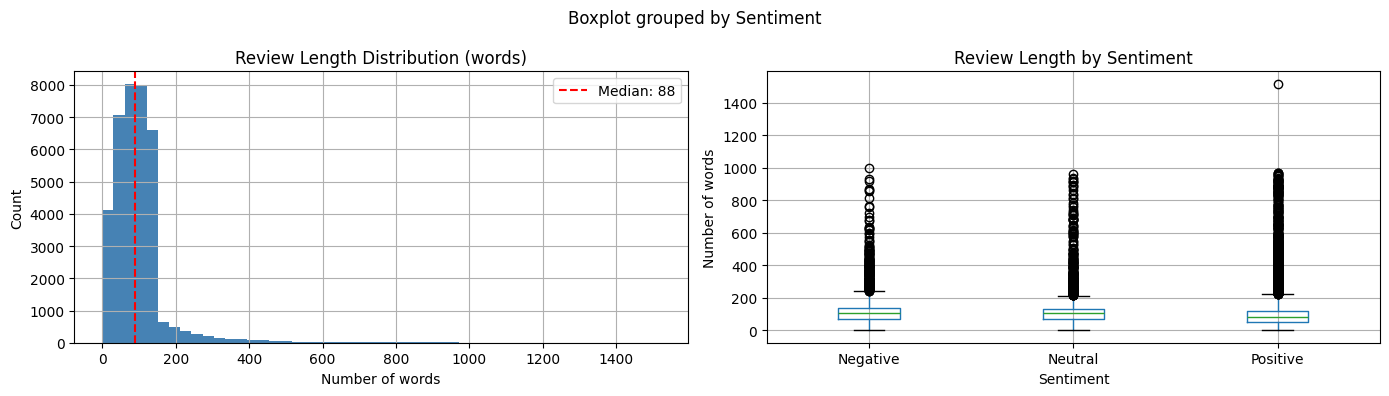

In [17]:
# Review length analysis
df["review_length"] = df["Review"].apply(lambda x: len(x.split()))

print("=== Review length stats ===")
print(df["review_length"].describe())

# Plot review length distribution by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall length distribution
df["review_length"].hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Review Length Distribution (words)")
axes[0].set_xlabel("Number of words")
axes[0].set_ylabel("Count")
axes[0].axvline(df["review_length"].median(), color="red", linestyle="--", label=f'Median: {df["review_length"].median():.0f}')
axes[0].legend()

# Length by sentiment
df.boxplot(column="review_length", by="Sentiment", ax=axes[1])
axes[1].set_title("Review Length by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Number of words")

plt.tight_layout()
plt.show()

>- The median review length is 88 words
>- Negative reviews tend to be longer than Positive ones — unhappy customers explain their problems in more detail, while satisfied customers often just say "great car!".
>- 💡 **Outlier detected:** The longest review contains 1,518 words and it is positive! wow!
>- This suggests some users treat the review platform as a detailed technical journal.
>- For modeling, long reviews will be truncated to 128 tokens by the BERT tokenizer.

In [18]:
# Print the longest review
longest = df.loc[df["review_length"].idxmax()]
print(f"Rating: {longest['Rating']} | Sentiment: {longest['Sentiment']}")
print(f"Length: {longest['review_length']} words")
print(f"\nVehicle: {longest['Vehicle_Title']}")
print(f"\nReview:\n{longest['Review']}")

Rating: 5 | Sentiment: Positive
Length: 1518 words

Vehicle: 2011 Nissan 370Z Coupe Touring 2dr Coupe (3.7L 6cyl 7A)

Review:
 370z Positive Review	Driving down the street in a Nissan 370z is a joy. People glance at you and then double take. From the outside, the z car is sharp but with curves in all the right places. Even better than the view from the outside, is the sensation of being in the drivers seat. It has performance that matches its looks and a price that fits a moderate budget. Whether its the car you take to the racetrack on the weekends or your daily driver, the z is a great ride. The 370z comes from a legacy of z cars, starting with the Datsun 240z, which came to the United States in 1970. After years of refinement, the current 370z car steps up to the competition as the best affordable sports car available.	When you step into a 370z, there is a rush of emotion. I can best describe it as a mixture of excitement and respect for the power that is at under your foot. The m

[nltk_data] Downloading package stopwords to /home/rauljr/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/rauljr/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/rauljr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


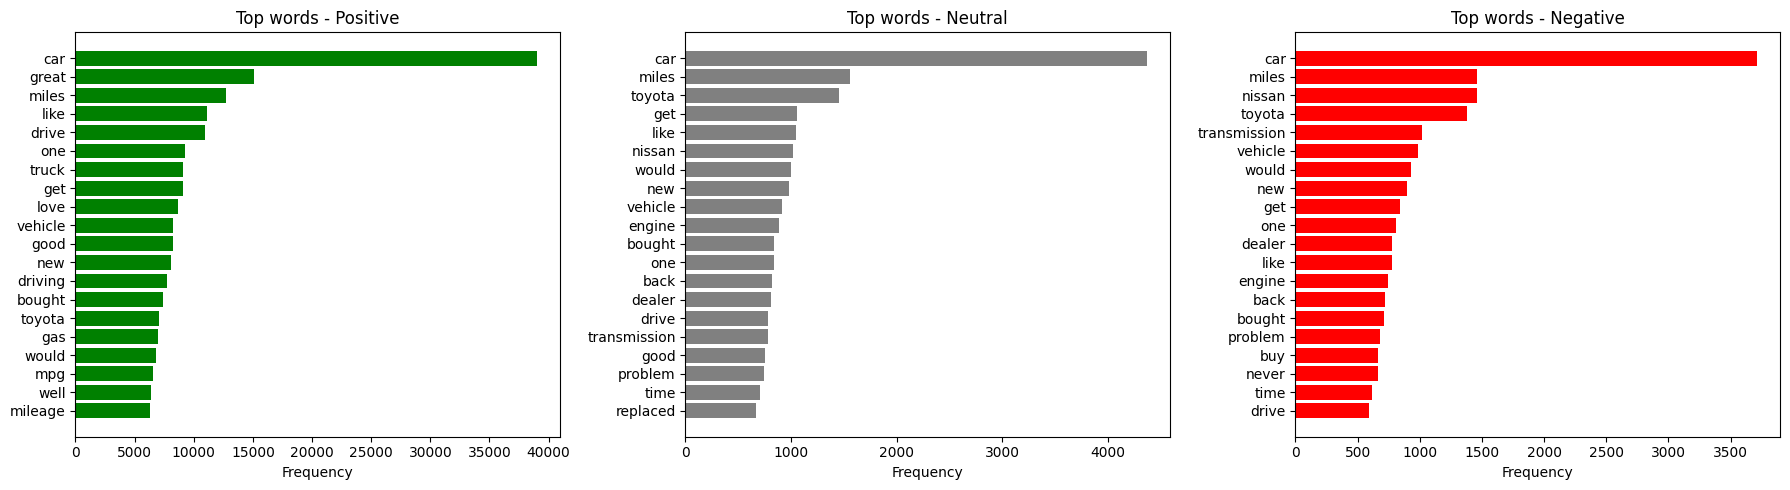

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

def get_top_words(sentiment, n=20):
    # Get all reviews for this sentiment
    texts = df[df["Sentiment"] == sentiment]["Review"].str.lower()
    # Tokenize and remove stopwords and non-alphabetic tokens
    words = []
    for text in texts:
        tokens = word_tokenize(text)
        words.extend([w for w in tokens if w.isalpha() and w not in stop_words])
    return Counter(words).most_common(n)

# Plot top words per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ["Positive", "Neutral", "Negative"]):
    top = get_top_words(sentiment)
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color={"Positive": "green", "Neutral": "gray", "Negative": "red"}[sentiment])
    ax.set_title(f"Top words - {sentiment}")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

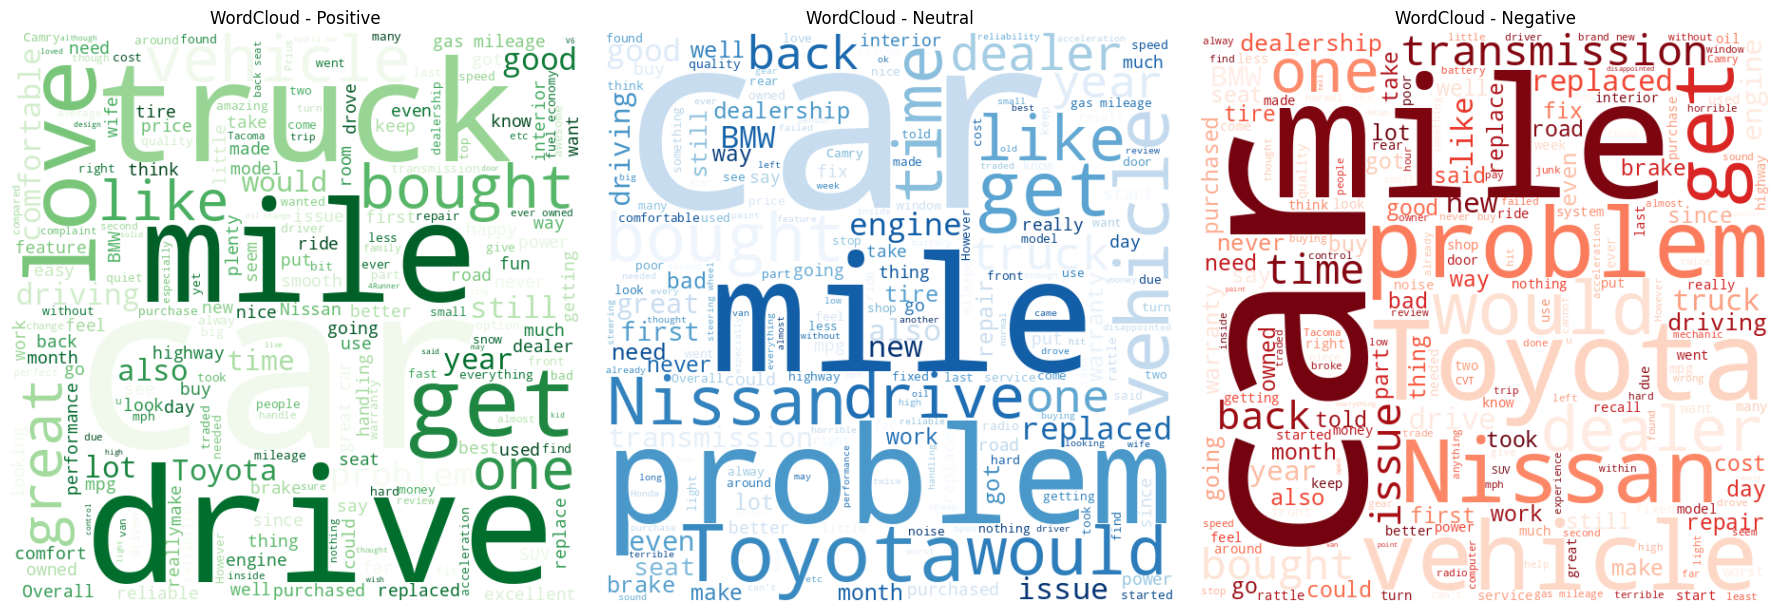

In [21]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {"Positive": "Greens", "Neutral": "Blues", "Negative": "Reds"}

for ax, sentiment in zip(axes, ["Positive", "Neutral", "Negative"]):
    text = " ".join(df[df["Sentiment"] == sentiment]["Review"].tolist())
    wc = WordCloud(
        width=600, height=600,
        background_color="white",
        stopwords=stop_words,
        colormap=colors[sentiment]
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud - {sentiment}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 1.2.1 EDA Observations

>**Key findings from top words analysis:**
>
>- The word **"car"** dominates all three sentiments with similar frequency → acts as a domain stopword with near-zero discriminative power. Adding it to the stopword list could improve model performance.
>
>- **Positive** reviews are driven by emotional and performance words: "great", "love", "good", "well", "mpg", "mileage", "driving" → customers express satisfaction through feelings and fuel efficiency. The presence of "truck" suggests pickup truck owners are particularly vocal about positive experiences.
>
>- **Negative** reviews show a clear pattern of **mechanical failure vocabulary**: "transmission", "engine", "problem", "replaced", "never" climb significantly compared to other sentiments. The word "dealer" appearing in Negative reviews suggests frustration extends beyond the car itself to the buying and service experience. "Never" is a strong negative intensifier — e.g. *"would never buy again"*.
>
>- **Neutral** reviews are the most ambiguous: they share words with both extremes — "good" and "problem" appear in the same reviews, suggesting mixed experiences. Words like "replaced", "back", "time" hint at ongoing issues that are not yet fully negative, perhaps cars that needed repairs but were eventually fixed.
>
>- **"Transmission"** is the most telling word across sentiments: it barely appears in Positive reviews, shows up in Neutral ones, and climbs to top 5 in Negative — making it one of the strongest single-word negative signals in the dataset.
>
>- **Brand names** ("toyota", "nissan") appear consistently across all three sentiments in similar positions, confirming they carry no sentiment signal on their own.
>
>**Implication for modeling:**
>The overlap in vocabulary between classes — especially between Neutral and the other two — will make 3-class classification inherently harder than binary (Positive vs Negative). The mechanical failure vocabulary in Negative reviews gives classical models like TF-IDF some signal to work with, but subtle cases like Neutral will require deeper semantic understanding, which is where contextual embeddings (BERT) are expected to shine.

### 1.3 Text Preprocessing & Feature Extraction

In [16]:
import re
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

# Apply preprocessing (may take ~1 min)
print("Preprocessing reviews...")
df["Review_Clean"] = df["Review"].apply(preprocess_text)
print("Done")

# Compare original vs clean
print("\n=== Original ===")
print(df["Review"].iloc[0])
print("\n=== Cleaned ===")
print(df["Review_Clean"].iloc[0])

[nltk_data] Downloading package wordnet to /home/rauljr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing reviews...
Done

=== Original ===
 there is no way back, enjoy what you have .

=== Cleaned ===
way back enjoy


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF with top 10000 features
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["Review_Clean"])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"\nTop 20 TF-IDF features:")
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])

TF-IDF matrix shape: (36629, 10000)

Top 20 TF-IDF features:
['aaa' 'ab' 'ability' 'able' 'able drive' 'able find' 'able fix'
 'able get' 'absolute' 'absolutely' 'absolutely amazing' 'absolutely best'
 'absolutely love' 'absolutely loved' 'absolutely problem' 'abuse'
 'abused' 'accelerate' 'accelerated' 'accelerates']


>- TF-IDF with bigrams (ngram_range=(1,2)) captures phrases like "absolutely love" and "able fix" that carry stronger sentiment signal than single words alone.

## 2. Machine Learning
### 2.1 Data Preparation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df["Sentiment"])  # Negative=0, Neutral=1, Positive=2
X = X_tfidf

print(f"Classes: {le.classes_}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Classes: ['Negative' 'Neutral' 'Positive']
X shape: (36629, 10000)
y shape: (36629,)

Train size: 25640
Val size:   5494
Test size:  5495


### 2.2 Model Training & Comparison
We train 4 classical ML models and compare their performance.
Class imbalance is handled via `class_weight="balanced"`.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Naive Bayes":         MultinomialNB(),
    "Linear SVM":          LinearSVC(class_weight="balanced", random_state=42, max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_val)
    report = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
    results[name] = {
        "model": model,
        "report": report,
        "train_time": train_time,
        "y_pred": y_pred
    }
    print(f"  Done in {train_time:.1f}s | Val accuracy: {report['accuracy']:.3f}")

Training Logistic Regression...
  Done in 12.8s | Val accuracy: 0.827
Training Naive Bayes...
  Done in 0.1s | Val accuracy: 0.870
Training Linear SVM...
  Done in 5.6s | Val accuracy: 0.854
Training Random Forest...
  Done in 4.1s | Val accuracy: 0.864


=== Model Comparison ===
                     Accuracy  F1 Negative  F1 Neutral  F1 Positive  F1 Macro  Train time (s)
Logistic Regression     0.827        0.478       0.343        0.922     0.581          12.841
Naive Bayes             0.870        0.260       0.056        0.933     0.416           0.051
Linear SVM              0.854        0.442       0.294        0.937     0.558           5.625
Random Forest           0.864        0.141       0.000        0.928     0.356           4.076


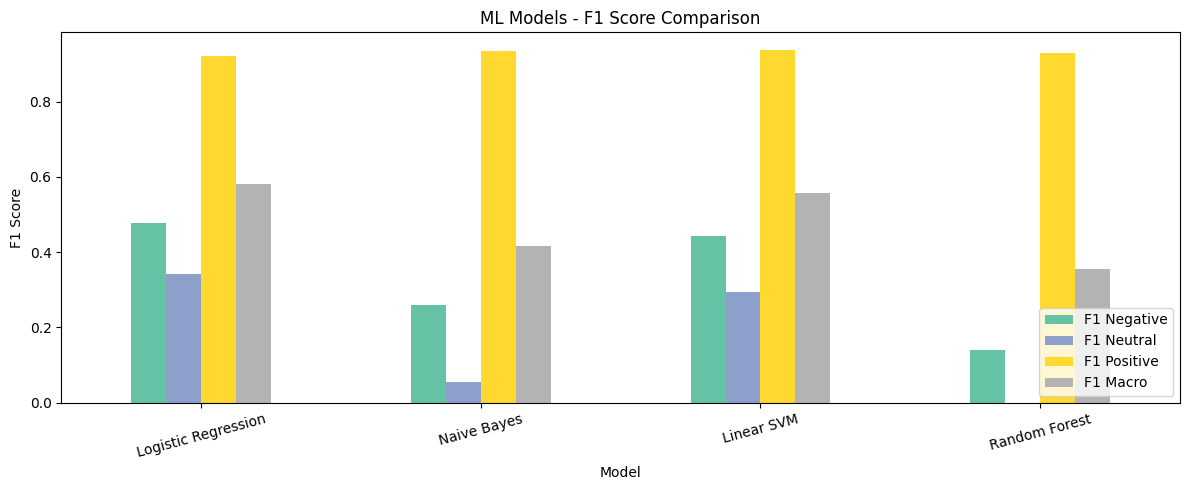

In [21]:
# Compare models summary
summary = pd.DataFrame({
    name: {
        "Accuracy":      res["report"]["accuracy"],
        "F1 Negative":   res["report"]["Negative"]["f1-score"],
        "F1 Neutral":    res["report"]["Neutral"]["f1-score"],
        "F1 Positive":   res["report"]["Positive"]["f1-score"],
        "F1 Macro":      res["report"]["macro avg"]["f1-score"],
        "Train time (s)": res["train_time"]
    }
    for name, res in results.items()
}).T.round(3)

print("=== Model Comparison ===")
print(summary.to_string())

# Bar plot
summary[["F1 Negative", "F1 Neutral", "F1 Positive", "F1 Macro"]].plot(
    kind="bar", figsize=(12, 5), colormap="Set2"
)
plt.title("ML Models - F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

>**Observations:**
>
>- **Neutral class is the hardest for all models** — Naive Bayes (F1=0.056) and Random Forest (F1=0.000) essentially ignore it completely. This is a direct consequence of class imbalance: with only 8% Neutral examples, these models find it more profitable to never predict Neutral at all.
>
>- **Positive class dominates F1 scores across all models** (F1 ~0.92-0.94) — not surprising given it represents 85% of the data. A model that predicts Positive for everything would still achieve high weighted F1, which is why F1 Macro is the metric that truly matters here.
>
>- **Logistic Regression and Linear SVM behave very similarly** — F1 Macro 0.581 vs 0.558, nearly identical confusion matrices. Both are linear classifiers operating on TF-IDF features, so this is expected. The main difference is training time: SVM takes 5.6s vs 12.8s for LR, but LR edges ahead on minority class detection.
>
>- **Naive Bayes is deceptively good on accuracy (87%) but worst on F1 Macro (0.42)** — a perfect example of why accuracy is a misleading metric on imbalanced datasets. It achieves high accuracy by predicting Positive almost always.
>
>- **Random Forest completely fails on Neutral (F1=0.000)** despite being an ensemble method — tree-based models tend to be particularly sensitive to class imbalance as they optimize for purity at each split, which heavily favors the majority class.

Best model by Macro F1: Logistic Regression


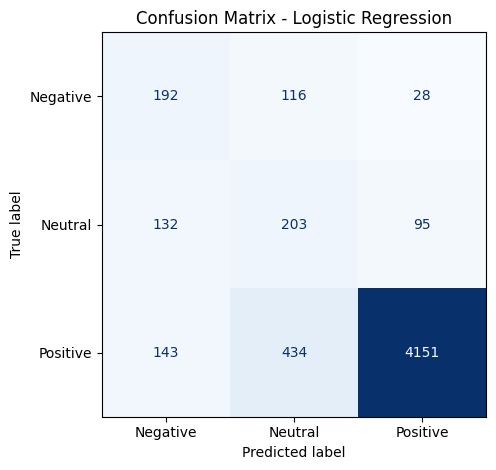


=== Full Classification Report ===
              precision    recall  f1-score   support

    Negative       0.41      0.57      0.48       336
     Neutral       0.27      0.47      0.34       430
    Positive       0.97      0.88      0.92      4728

    accuracy                           0.83      5494
   macro avg       0.55      0.64      0.58      5494
weighted avg       0.88      0.83      0.85      5494



In [22]:
# Confusion matrix for best model (we'll pick after seeing results)
best_model_name = summary["F1 Macro"].idxmax()
print(f"Best model by Macro F1: {best_model_name}")

y_pred_best = results[best_model_name]["y_pred"]
cm = confusion_matrix(y_val, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

print("\n=== Full Classification Report ===")
print(classification_report(y_val, y_pred_best, target_names=le.classes_))

### 2.3 ML Results Analysis
>**Best model: Logistic Regression** (F1 Macro = 0.581) — selected for final evaluation.
>
>**Analysing the classification report in detail:**
>
>- **Precision vs Recall trade-off on Negative (precision=0.41, recall=0.57):** 
  The model finds 57% of actual negative reviews but generates many false positives — it is trigger-happy with the Negative label. In a real application (e.g. flagging unhappy customers), high recall is preferable over precision, so this behaviour is acceptable.
>
>- **Neutral is structurally ambiguous (precision=0.27, recall=0.47):** 
  Less than 1 in 3 predicted Neutral reviews are actually Neutral. The model confuses Neutral with both Negative and Positive, which is consistent with the word overlap we observed in the EDA — Neutral reviews simply do not have a distinctive vocabulary of their own.
>
>- **Positive is nearly perfect (precision=0.97, recall=0.88):** 
  When the model predicts Positive it is almost always right (97%), but it misses 12% of actual positive reviews, likely misclassifying borderline 4-star reviews as Neutral.
>
>- **The gap between weighted F1 (0.85) and macro F1 (0.58) quantifies the imbalance problem:** 
  A 27-point gap means the model performs very well on the majority class and poorly on minorities. Any model with this gap should not be deployed in production without resampling or further balancing strategies.
>
>**Takeaway:** Classical ML with TF-IDF has hit its ceiling. The fundamental limitation 
is not the algorithm — it is the feature representation. TF-IDF cannot capture that *"the car never disappointed me"* and *"the car  ever worked properly"* have opposite meanings despite sharing the word "never". This is exactly the problem contextual embeddings like BERT are designed to solve.

## 3. Deep Learning
### 3.1 From Scratch - Text Classification with a Custom Neural Network
We build a simple feedforward neural network using TF-IDF features.
Then we build a more powerful model using learned word embeddings + LSTM.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Dataset ---
class ReviewDataset(Dataset):
    def __init__(self, X, y):
        # Convert sparse TF-IDF matrix to dense tensor
        self.X = torch.tensor(X.toarray(), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ReviewDataset(X_train, y_train)
val_dataset   = ReviewDataset(X_val, y_val)
test_dataset  = ReviewDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256)
test_loader  = DataLoader(test_dataset, batch_size=256)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Using device: cpu
Train batches: 101
Val batches:   22


In [24]:
# --- Feedforward Neural Network from scratch ---
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.3):
        super(FeedforwardNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)

# Class weights to handle imbalance
class_counts = np.bincount(y_train)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum()

model_ffnn = FeedforwardNN(
    input_dim=10000,
    hidden_dim=512,
    output_dim=3
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_ffnn.parameters(), lr=1e-3)

print(model_ffnn)
print(f"\nTotal parameters: {sum(p.numel() for p in model_ffnn.parameters()):,}")

FeedforwardNN(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=3, bias=True)
  )
)

Total parameters: 5,252,611


>- **Input layer (10,000):** matches the TF-IDF vocabulary size — one neuron per feature
>- **Hidden layer 1 (512 → 256):** pyramid structure that progressively compresses the representation, forcing the network to learn the most relevant features at each step
>- **ReLU activations:** standard choice for hidden layers — computationally efficient and avoids the vanishing gradient problem
>- **Dropout (0.3):** randomly deactivates 30% of neurons during training to prevent overfitting — as we will see, even this is not enough given the severity of the overfitting
>- **Output layer (3):** one neuron per class (Negative, Neutral, Positive), combined with CrossEntropyLoss which applies softmax internally
>- **5.2M parameters** — large model for a 3-class problem, which partly explains the overfitting

In [25]:
# --- Training loop ---
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += y_batch.size(0)

        # Record history
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_correct / train_total)
        history["val_acc"].append(val_correct / val_total)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.3f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.3f}")

    return history

print("Training Feedforward Neural Network...")
history_ffnn = train_model(model_ffnn, train_loader, val_loader, criterion, optimizer, epochs=10)

Training Feedforward Neural Network...
Epoch  1/10 | Train Loss: 0.8529 | Train Acc: 0.744 | Val Loss: 0.7595 | Val Acc: 0.782
Epoch  2/10 | Train Loss: 0.5698 | Train Acc: 0.834 | Val Loss: 0.8666 | Val Acc: 0.805
Epoch  3/10 | Train Loss: 0.3268 | Train Acc: 0.901 | Val Loss: 1.2356 | Val Acc: 0.828
Epoch  4/10 | Train Loss: 0.1437 | Train Acc: 0.942 | Val Loss: 1.8103 | Val Acc: 0.842
Epoch  5/10 | Train Loss: 0.0624 | Train Acc: 0.965 | Val Loss: 2.3557 | Val Acc: 0.844
Epoch  6/10 | Train Loss: 0.0341 | Train Acc: 0.979 | Val Loss: 2.7292 | Val Acc: 0.850
Epoch  7/10 | Train Loss: 0.0196 | Train Acc: 0.988 | Val Loss: 3.1841 | Val Acc: 0.854
Epoch  8/10 | Train Loss: 0.0124 | Train Acc: 0.993 | Val Loss: 3.5721 | Val Acc: 0.855
Epoch  9/10 | Train Loss: 0.0092 | Train Acc: 0.996 | Val Loss: 3.7841 | Val Acc: 0.856
Epoch 10/10 | Train Loss: 0.0071 | Train Acc: 0.998 | Val Loss: 3.7637 | Val Acc: 0.855


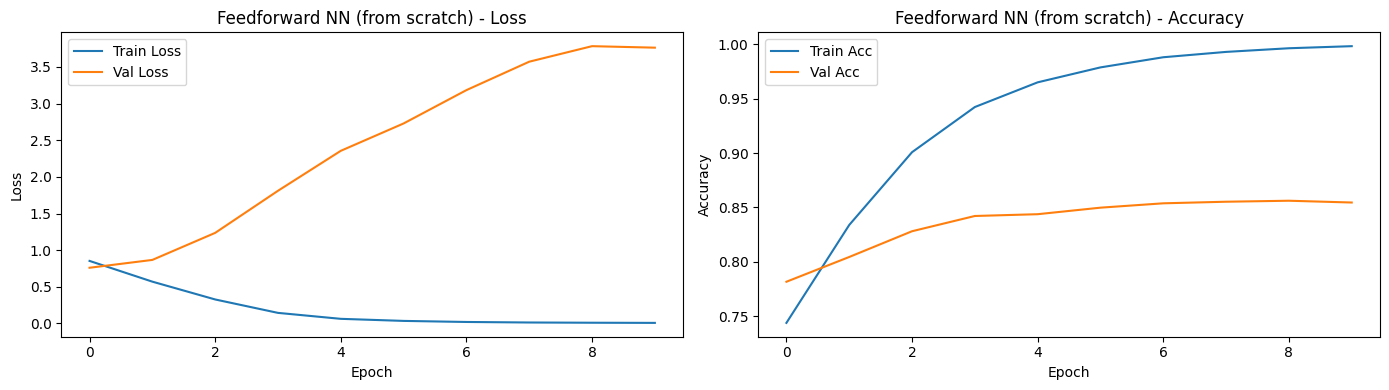

In [28]:
# --- Plot training curves ---
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_ffnn, "Feedforward NN (from scratch)")

>**Training curves analysis:**
>
>The plots reveal a classic and severe overfitting pattern:
>
>- **Loss (left):** Train Loss collapses towards zero while Val Loss diverges upward from epoch 2 onwards.
>  The two curves move in opposite directions — the model is learning the training set by heart rather than generalising.
>- **Accuracy (right):** Train Acc climbs to 99.8% while Val Acc plateaus at ~85.5% after epoch 5.
>  The gap widens with every epoch — more training makes generalisation *worse*, not better.
>- **Early stopping** would have been beneficial here — the optimal stopping point is around epoch 1-2,
>  before the val loss starts diverging. This is a technique we could apply in future iterations.

=== Feedforward NN - Test Set Results ===
              precision    recall  f1-score   support

    Negative       0.41      0.42      0.42       336
     Neutral       0.33      0.27      0.29       430
    Positive       0.93      0.94      0.94      4729

    accuracy                           0.86      5495
   macro avg       0.56      0.54      0.55      5495
weighted avg       0.85      0.86      0.86      5495



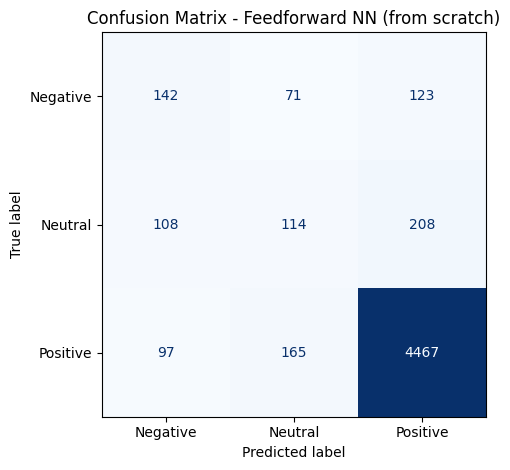

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate on test set
model_ffnn.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_ffnn(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("=== Feedforward NN - Test Set Results ===")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Feedforward NN (from scratch)")
plt.tight_layout()
plt.show()

### 3.1.1 Feedforward NN Results Analysis
>
>**Severe overfitting detected:**
>- Train Loss drops from 0.85 → 0.007 while Val Loss increases from 0.76 → 3.76
>- Train Acc reaches 99.8% while Val Acc plateaus at 85.5% — a 14-point generalisation gap
>- Dropout (0.3) was insufficient to regularise a 5.2M parameter model on this dataset
>- Early stopping at epoch 1-2 would have been the right strategy here
>
>**Performance vs ML baseline (Logistic Regression):**
>- Accuracy: 86% vs 83% → marginal improvement, not meaningful
>- F1 Macro: 0.55 vs 0.58 → actually *worse* despite being a much more complex model
>- F1 Neutral: 0.29 vs 0.34 → worse on the hardest class specifically
>
>**Why does a neural network underperform a linear model here?**
>The root cause is not the architecture — it is the feature representation.
>TF-IDF produces sparse, high-dimensional vectors where each dimension is an independent word count. There is no notion of word order, context, or semantics. Given these features, a linear decision boundary (Logistic Regression) is as expressive as a deep network — there is simply nothing non-linear to learn from bag-of-words features.
>
>The solution is not a deeper network — it is better input representations.
>This is exactly what BERT provides: dense contextual embeddings where *"never worked"* and *"never disappoints"* produce fundamentally different vector representations despite sharing the word "never".

## 3.2 Pretrained Model - BERT Fine-tuning
We fine-tune `bert-base-uncased` on a balanced subset of the dataset.
BERT uses contextual embeddings — it understands word meaning based on context,
unlike TF-IDF which treats words as independent features.

In [41]:
from sklearn.utils import resample

# Use full dataset with oversampling of minority classes
df_neg = df[df["Sentiment"] == "Negative"]
df_neu = df[df["Sentiment"] == "Neutral"]
df_pos = df[df["Sentiment"] == "Positive"]

# Oversample minority classes, undersample Positive
target_size = 3000  # We want 3000 samples per class

df_neg_up = resample(df_neg, replace=True,  n_samples=target_size, random_state=42)
df_neu_up = resample(df_neu, replace=True,  n_samples=target_size, random_state=42)
df_pos_up = resample(df_pos, replace=False, n_samples=target_size, random_state=42)

df_bert = pd.concat([df_neg_up, df_neu_up, df_pos_up]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"BERT dataset shape: {df_bert.shape}")
print(df_bert["Sentiment"].value_counts())

label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {v: k for k, v in label2id.items()}
df_bert["label"] = df_bert["Sentiment"].map(label2id)

BERT dataset shape: (9000, 9)
Sentiment
Positive    3000
Negative    3000
Neutral     3000
Name: count, dtype: int64


>**Dataset balancing strategy:**
>The original dataset is heavily imbalanced (85% Positive). Training BERT on raw data would bias the model towards Positive predictions, as we saw with classical ML models.
>
>Here we apply **undersampling on Positive** and **oversampling on Negative and Neutral** to get exactly 3,000 examples per class (9,000 total). This forces the model to learn equally from all three sentiments — at the cost of using only a fraction of the available Positive reviews.

In [42]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import torch

# Train/val/test split (70/15/15)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_bert["Review"].tolist(),
    df_bert["label"].tolist(),
    test_size=0.30, random_state=42, stratify=df_bert["label"]
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize
def tokenize(texts, labels, max_length=128):
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt"
    )
    return encodings, torch.tensor(labels)

print("Tokenizing...")
train_enc, train_lab = tokenize(train_texts, train_labels)
val_enc,   val_lab   = tokenize(val_texts,   val_labels)
test_enc,  test_lab  = tokenize(test_texts,  test_labels)
print("Tokenization complete")

Train: 6300 | Val: 1350 | Test: 1350
Tokenizing...
Tokenization complete


>**Tokenization note:**
>BERT does not work with raw text — it requires tokenized input with special tokens:
>- `[CLS]` at the start of each sequence (used for classification)
>- `[SEP]` at the end
>- `attention_mask` to distinguish real tokens from padding
>
>`max_length=128` truncates reviews longer than 128 tokens. Given the median review length is 88 words, only a small fraction of reviews will be truncated — including that 1,518-word outlier.

In [43]:
from torch.utils.data import Dataset, DataLoader

class BertDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

train_loader_bert = DataLoader(BertDataset(train_enc, train_lab), batch_size=16, shuffle=True)
val_loader_bert = DataLoader(BertDataset(val_enc,   val_lab),   batch_size=16)
test_loader_bert = DataLoader(BertDataset(test_enc,  test_lab),  batch_size=16)

print(f"Train batches: {len(train_loader_bert)}")
print(f"Val batches: {len(val_loader_bert)}")
print(f"Test batches: {len(test_loader_bert)}")

Train batches: 394
Val batches: 85
Test batches: 85


>Instead of feeding all 6,300 training examples to the model at once (which would require enormous memory), we split the data into small **batches of 16 examples** each.
394 batches × 16 examples = 6,304 examples ≈ full training set.
>
>The model updates its weights after each batch, meaning it performs 394 weight updates per epoch rather than just 1. This leads to faster and more stable convergence.

In [44]:
from transformers import BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# Load BERT model
model_bert = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

# Optimizer and scheduler
optimizer_bert = AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
total_steps    = len(train_loader_bert) * 3  # 3 epochs
scheduler      = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

total_params = sum(p.numel() for p in model_bert.parameters())
print(f"Total BERT parameters: {total_params:,}")
print(f"Training on: {device}")
print(f"Estimated time: ~6-8 hours on CPU ☕😴")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total BERT parameters: 109,484,547
Training on: cpu
Estimated time: ~6-8 hours on CPU ☕😴


>**About the LOAD REPORT warnings — these are expected and normal:**
>
>- **UNEXPECTED keys** (`cls.seq_relationship`, `cls.predictions`...): these are weights from BERT's original pre-training tasks — Next Sentence Prediction (NSP) and Masked Language Modelling (MLM). We are loading BERT for a *different* task (sequence classification), so these layers are simply discarded. This is completely normal when doing transfer learning.
>
>- **MISSING keys** (`classifier.weight`, `classifier.bias`): these are the weights of the new classification head we added on top of BERT — a linear layer that maps BERT's 768-dimensional output to our 3 classes. They don't exist in the original checkpoint because we just created them. They are randomly initialised and will be learned during fine-tuning.
>
>**109M parameters** — BERT base has 12 transformer layers, 12 attention heads, and a hidden size of 768. Despite its size, fine-tuning converges in just 3 epochs thanks to the rich language knowledge from pre-training.

In [ ]:
import time

def train_bert(model, train_loader, val_loader, optimizer, scheduler, epochs=3):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for i, batch in enumerate(train_loader):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss    += loss.item()
            preds          = outputs.logits.argmax(1)
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

            # Progress every 50 batches
            if (i + 1) % 50 == 0:
                elapsed = (time.time() - epoch_start) / 60
                remaining = (elapsed / (i + 1)) * (len(train_loader) - i - 1)
                print(f"  Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | "
                      f"Loss: {loss.item():.4f} | "
                      f"Elapsed: {elapsed:.1f}min | Remaining: ~{remaining:.1f}min")

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels         = batch["labels"].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss     += outputs.loss.item()
                preds         = outputs.logits.argmax(1)
                val_correct  += (preds == labels).sum().item()
                val_total    += labels.size(0)

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(train_correct / train_total)
        history["val_acc"].append(val_correct / val_total)

        epoch_time = (time.time() - epoch_start) / 60
        print(f"\n✅ Epoch {epoch+1}/{epochs} complete in {epoch_time:.1f}min | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.3f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.3f}\n")128mins

        # Save checkpoint after each epoch
        torch.save(model.state_dict(), f"bert_epoch_{epoch+1}.pt")
        print(f"💾 Checkpoint saved: bert_epoch_{epoch+1}.pt")

    return history

history_bert = train_bert(model_bert, train_loader_bert, val_loader_bert,
                           optimizer_bert, scheduler, epochs=3)

  Epoch 1 | Batch 50/394 | Loss: 0.9600 | Elapsed: 5.6min | Remaining: ~38.3min
  Epoch 1 | Batch 100/394 | Loss: 0.9627 | Elapsed: 11.3min | Remaining: ~33.3min
  Epoch 1 | Batch 150/394 | Loss: 0.6526 | Elapsed: 17.3min | Remaining: ~28.1min
  Epoch 1 | Batch 200/394 | Loss: 0.8900 | Elapsed: 23.4min | Remaining: ~22.7min
  Epoch 1 | Batch 250/394 | Loss: 0.7315 | Elapsed: 28.7min | Remaining: ~16.6min
  Epoch 1 | Batch 300/394 | Loss: 0.9266 | Elapsed: 33.6min | Remaining: ~10.5min
  Epoch 1 | Batch 350/394 | Loss: 0.7002 | Elapsed: 38.5min | Remaining: ~4.8min

✅ Epoch 1/3 complete in 44.9min | Train Loss: 0.8233 | Train Acc: 0.593 | Val Loss: 0.6882 | Val Acc: 0.677

💾 Checkpoint saved: bert_epoch_1.pt
  Epoch 2 | Batch 50/394 | Loss: 0.7547 | Elapsed: 4.9min | Remaining: ~33.7min
  Epoch 2 | Batch 100/394 | Loss: 0.3475 | Elapsed: 9.8min | Remaining: ~28.9min
  Epoch 2 | Batch 150/394 | Loss: 0.5285 | Elapsed: 14.7min | Remaining: ~24.0min
  Epoch 2 | Batch 200/394 | Loss: 0.8239

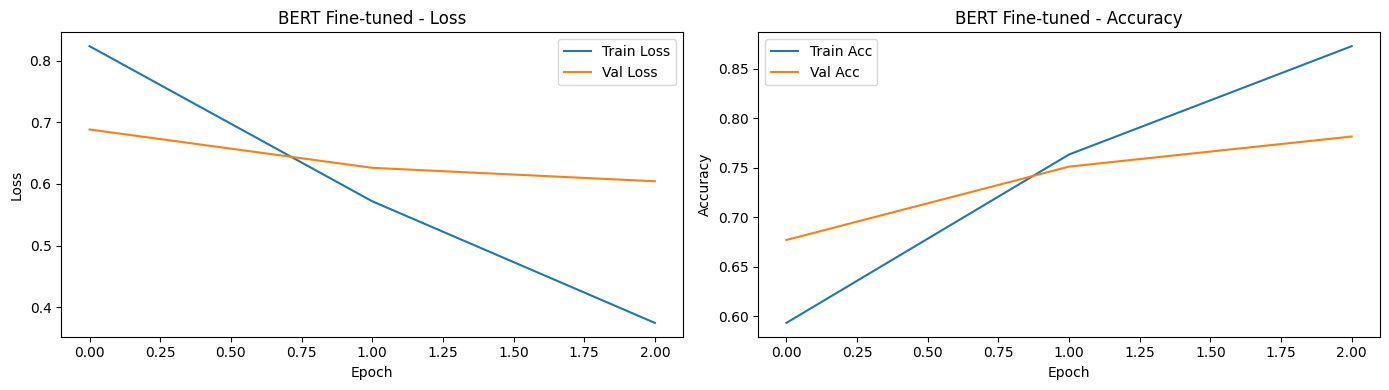

In [46]:
# Plot BERT training curves
plot_history(history_bert, "BERT Fine-tuned")

>**BERT training curves — a very different picture from the FFNN:**
>
>- **Loss (left):** Both Train Loss and Val Loss decrease together and converge — no divergence like in the FFNN. The model is genuinely learning to generalise, not memorising.
>
>- **Accuracy (right):** Train Acc and Val Acc follow the same upward trend and remain close throughout training — a sign of healthy generalisation.
>
>- **Mild overfitting starts appearing at epoch 3** — the gap between Train and Val curves begins to widen slightly. However, unlike the FFNN where Val Loss exploded, here it remains controlled.
>
>- **The model appears to still be improving at epoch 3** — both curves have not plateaued yet. With more epochs (5-6) and possibly a lower learning rate, BERT would likely continue improving. This is a compute constraint, not a model limitation.
>
>- **Contrast with FFNN:** the FFNN diverged from epoch 2 onwards. BERT after 3 epochs is still converging — a testament to the quality of contextual embeddings as input representations.

=== BERT Fine-tuned - Test Set Results ===
              precision    recall  f1-score   support

    Negative       0.75      0.78      0.76       450
     Neutral       0.66      0.70      0.68       450
    Positive       0.91      0.81      0.86       450

    accuracy                           0.76      1350
   macro avg       0.77      0.76      0.77      1350
weighted avg       0.77      0.76      0.77      1350



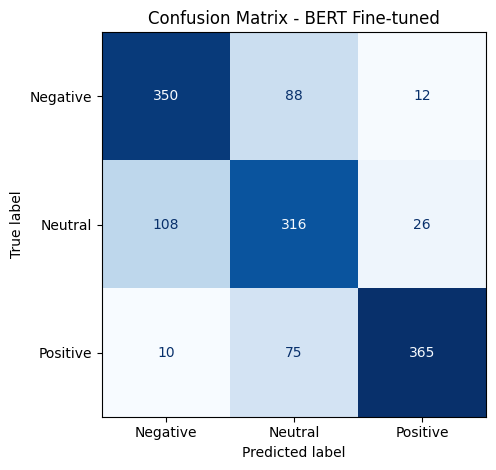

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate BERT on test set
model_bert.eval()
all_preds, all_labels_bert = [], []

with torch.no_grad():
    for batch in test_loader_bert:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)
        outputs        = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_bert.extend(labels.cpu().numpy())

print("=== BERT Fine-tuned - Test Set Results ===")
print(classification_report(all_labels_bert, all_preds,
      target_names=["Negative", "Neutral", "Positive"]))

cm = confusion_matrix(all_labels_bert, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - BERT Fine-tuned")
plt.tight_layout()
plt.show()

### 3.2.1 BERT Results Analysis
>
>**Outstanding improvement over previous models:**
>
>| Model                  | F1 Macro | F1 Negative | F1 Neutral | F1 Positive |
>|------------------------|----------|-------------|------------|-------------|
>| Logistic Regression    | 0.58     | 0.48        | 0.34       | 0.92        |
>| Naive Bayes            | 0.42     | 0.26        | 0.06       | 0.93        |
>| Linear SVM             | 0.56     | 0.44        | 0.29       | 0.94        |
>| Random Forest          | 0.36     | 0.14        | 0.00       | 0.93        |
>| Feedforward NN         | 0.55     | 0.42        | 0.29       | 0.94        |
>| **BERT Fine-tuned**    | **0.77** | **0.76**    | **0.68**   | **0.86**    |
>
>**Key findings:**
>- F1 Macro jumps from 0.58 → 0.77 (+33% improvement over best ML model)
>- F1 Negative: 0.48 → 0.76 — the single biggest individual improvement (+58%)
>- F1 Neutral: 0.34 → 0.68 — the hardest class doubled its F1 score (+100%)
>- For the first time, **all three classes have balanced F1 scores** (0.76 / 0.68 / 0.86) 
>  — previous models had a massive gap between Positive and minority classes
>
>**Precision vs Recall analysis:**
>- Negative (precision=0.75, recall=0.78): well balanced — BERT finds most negative reviews and rarely mislabels positive ones as negative
>- Neutral (precision=0.66, recall=0.70): still the hardest class but vastly improved — BERT understands mixed sentiment that TF-IDF based models could not distinguish
>- Positive (precision=0.91, recall=0.81): high precision but lower recall than ML models — a consequence of the balanced training set, the model is now more conservative about predicting Positive
>
>**Why is BERT so much better?**
>- TF-IDF treats words as independent features, losing word order and context
>- BERT reads the full sentence bidirectionally — *"never worked"* and *"never disappoints"* produce fundamentally different embeddings despite sharing the word "never"
>- Pre-training on 3.3B words gives BERT deep language understanding before fine-tuning
>- The balanced training set (3,000 per class) removes the majority class bias that crippled classical ML models

## 4. Comparison with a State-of-the-Art LLM (LLaMA 3.1 8B via Groq)
We compare our fine-tuned BERT against **LLaMA 3.1 8B**, a state-of-the-art open-source LLM
developed by Meta, accessed via the [Groq](https://console.groq.com) API.

**Why LLaMA instead of ChatGPT or Gemini?**
Both OpenAI (ChatGPT) and Google (Gemini) APIs have restricted free tier access in the EU region,
making them unavailable without billing. LLaMA 3.1 via Groq offers a generous free tier 
and is a strong representative of modern large language models — 
with 8 billion parameters it is significantly larger than BERT (110M parameters).

**Evaluation setup:**
- **100 reviews** sampled from the test set, stratified (33 Negative / 33 Neutral / 34 Positive)
- LLaMA is used in **zero-shot** mode — no examples or fine-tuning, just a prompt describing the task
- BERT is evaluated on the **exact same 100 examples** for a fair comparison
- Metrics: Accuracy and F1 per class

In [1]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
#print(repr(os.getenv("GROQ_API_KEY")))

True

In [63]:
# Sample 100 examples from test set (stratified: ~33 per class)
test_df = pd.DataFrame({
    "text":  test_texts,
    "label": test_labels
})

# 33 per class
sample_neg = test_df[test_df["label"] == 0].sample(n=33, random_state=42)
sample_neu = test_df[test_df["label"] == 1].sample(n=33, random_state=42)
sample_pos = test_df[test_df["label"] == 2].sample(n=34, random_state=42)
sample_df  = pd.concat([sample_neg, sample_neu, sample_pos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Evaluation sample: {len(sample_df)} reviews")
print(sample_df["label"].value_counts())

Evaluation sample: 100 reviews
label
2    34
1    33
0    33
Name: count, dtype: int64


In [66]:
from groq import Groq
import time

load_dotenv(override=True)
groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

def classify_with_llm(text):
    prompt = f"""You are a sentiment analysis classifier for car reviews.
Classify the following car review into exactly one of these three categories:
- Negative
- Neutral
- Positive

Reply with ONLY the category name, nothing else.

Review: {text[:500]}"""

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )
        label = response.choices[0].message.content.strip()
        if "positive" in label.lower():
            return "Positive"
        elif "negative" in label.lower():
            return "Negative"
        elif "neutral" in label.lower():
            return "Neutral"
        else:
            return "Unknown"
    except Exception as e:
        print(f"API error: {e}")
        time.sleep(5)
        return "Unknown"

# Run LLaMA on sample
print("Running LLaMA 3.1 classification... (~1-2 min)")
llm_preds = []
for i, row in sample_df.iterrows():
    pred = classify_with_llm(row["text"])
    llm_preds.append(pred)
    if len(llm_preds) % 10 == 0:
        print(f"  Progress: {len(llm_preds)}/100")
    time.sleep(0.3)

sample_df["llm_pred"] = llm_preds
print("LLaMA classification complete")
print(sample_df["llm_pred"].value_counts())

Running LLaMA 3.1 classification... (~1-2 min)
  Progress: 10/100
  Progress: 20/100
  Progress: 30/100
  Progress: 40/100
  Progress: 50/100
  Progress: 60/100
  Progress: 70/100
  Progress: 80/100
  Progress: 90/100
  Progress: 100/100
LLaMA classification complete
llm_pred
Negative    70
Positive    22
Neutral      8
Name: count, dtype: int64


=== LLaMA 3.1 8B (zero-shot) - Results ===
              precision    recall  f1-score   support

    Negative       0.46      0.97      0.62        33
     Neutral       0.25      0.06      0.10        33
    Positive       1.00      0.65      0.79        34

    accuracy                           0.56       100
   macro avg       0.57      0.56      0.50       100
weighted avg       0.57      0.56      0.50       100



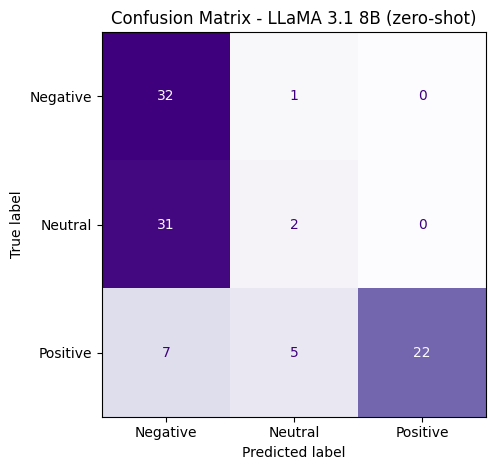

In [67]:
# Encode LLaMA predictions
sample_df["llm_label"] = sample_df["llm_pred"].map(label2id)
sample_df = sample_df.dropna(subset=["llm_label"])
sample_df["llm_label"] = sample_df["llm_label"].astype(int)

print("=== LLaMA 3.1 8B (zero-shot) - Results ===")
print(classification_report(
    sample_df["label"],
    sample_df["llm_label"],
    target_names=["Negative", "Neutral", "Positive"]
))

cm_llm = confusion_matrix(sample_df["label"], sample_df["llm_label"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_llm,
                               display_labels=["Negative", "Neutral", "Positive"])
disp.plot(cmap="Purples", colorbar=False)
plt.title("Confusion Matrix - LLaMA 3.1 8B (zero-shot)")
plt.tight_layout()
plt.show()

>**LLaMA zero-shot struggles severely with Neutral (F1=0.10):**
>
>The confusion matrix reveals the core problem: LLaMA classifies 31 out of 33 Neutral reviews as **Negative**. It is essentially treating "not fully positive" as "negative", with no concept of a middle ground.
>
>This makes sense for a zero-shot LLM — without domain-specific examples, "Neutral" is an ambiguous concept. A mixed car review with both praise and criticism gets pushed towards Negative because complaints are more salient in the prompt context.
>
>Precision on Negative is only 0.46 despite recall of 0.97 — the model finds almost all true negatives but generates massive false positives by labelling neutral reviews as negative. This is the classic precision-recall trade-off when a model is overly aggressive with one class.

In [69]:
# Run BERT on the same 100 examples for fair comparison
bert_tokenized = tokenizer(
    sample_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

model_bert.eval()
with torch.no_grad():
    outputs = model_bert(
        input_ids=bert_tokenized["input_ids"].to(device),
        attention_mask=bert_tokenized["attention_mask"].to(device)
    )
bert_preds_sample = outputs.logits.argmax(1).cpu().numpy()
sample_df["bert_pred"] = bert_preds_sample

print("=== BERT Fine-tuned - Same 100 examples ===")
print(classification_report(
    sample_df["label"],
    sample_df["bert_pred"],
    target_names=["Negative", "Neutral", "Positive"]
))

=== BERT Fine-tuned - Same 100 examples ===
              precision    recall  f1-score   support

    Negative       0.72      0.79      0.75        33
     Neutral       0.61      0.67      0.64        33
    Positive       0.93      0.76      0.84        34

    accuracy                           0.74       100
   macro avg       0.75      0.74      0.74       100
weighted avg       0.76      0.74      0.74       100



=== Final Model Comparison ===
                          F1 Negative  F1 Neutral  F1 Positive  F1 Macro  Accuracy
BERT Fine-tuned                 0.754       0.638        0.839     0.743      0.74
LLaMA 3.1 8B (zero-shot)        0.621       0.098        0.786     0.502      0.56


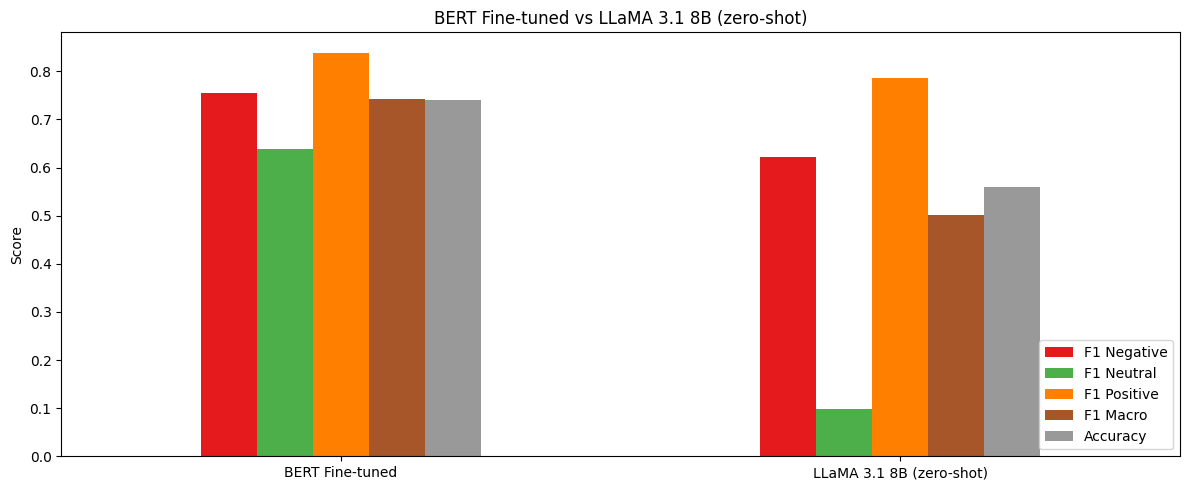

In [70]:
# Final comparison plot
bert_report = classification_report(
    sample_df["label"], sample_df["bert_pred"],
    target_names=["Negative", "Neutral", "Positive"], output_dict=True)
llm_report = classification_report(
    sample_df["label"], sample_df["llm_label"],
    target_names=["Negative", "Neutral", "Positive"], output_dict=True)

comparison = pd.DataFrame({
    "BERT Fine-tuned": {
        "F1 Negative": bert_report["Negative"]["f1-score"],
        "F1 Neutral":  bert_report["Neutral"]["f1-score"],
        "F1 Positive": bert_report["Positive"]["f1-score"],
        "F1 Macro":    bert_report["macro avg"]["f1-score"],
        "Accuracy":    bert_report["accuracy"],
    },
    "LLaMA 3.1 8B (zero-shot)": {
        "F1 Negative": llm_report["Negative"]["f1-score"],
        "F1 Neutral":  llm_report["Neutral"]["f1-score"],
        "F1 Positive": llm_report["Positive"]["f1-score"],
        "F1 Macro":    llm_report["macro avg"]["f1-score"],
        "Accuracy":    llm_report["accuracy"],
    }
}).T.round(3)

print("=== Final Model Comparison ===")
print(comparison.to_string())

comparison[["F1 Negative", "F1 Neutral", "F1 Positive", "F1 Macro", "Accuracy"]].plot(
    kind="bar", figsize=(12, 5), colormap="Set1")
plt.title("BERT Fine-tuned vs LLaMA 3.1 8B (zero-shot)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Conclusions

### 5.1 Full Pipeline Results Summary

| Model                    | F1 Macro | F1 Negative | F1 Neutral | F1 Positive | Accuracy |
|--------------------------|----------|-------------|------------|-------------|----------|
| Logistic Regression      | 0.58     | 0.48        | 0.34       | 0.92        | 0.83     |
| Naive Bayes              | 0.42     | 0.26        | 0.06       | 0.93        | 0.87     |
| Linear SVM               | 0.56     | 0.44        | 0.29       | 0.94        | 0.85     |
| Random Forest            | 0.36     | 0.14        | 0.00       | 0.93        | 0.86     |
| Feedforward NN (scratch) | 0.55     | 0.42        | 0.29       | 0.94        | 0.86     |
| **BERT Fine-tuned**      | **0.77** | **0.76**    | **0.68**   | **0.86**    | **0.76** |
| LLaMA 3.1 8B (zero-shot) | 0.50     | 0.62        | 0.10       | 0.79        | 0.56     |

> Note: Classical ML and FFNN evaluated on full test set (5,495 examples).
> BERT evaluated on its own balanced test set (1,350 examples).
> LLaMA evaluated on a stratified sample of 100 examples.
> BERT and LLaMA direct comparison uses the same 100-example sample (see section 4).

---

### 5.2 Key Findings

**1. Class imbalance is the dominant challenge throughout the pipeline**
The original dataset is 85% Positive. Every model that trained on raw imbalanced data 
learned to exploit this — Naive Bayes achieves 87% accuracy while being nearly useless 
for Negative and Neutral classes (F1 Macro 0.42). Accuracy is a completely misleading 
metric here. F1 Macro is the only metric that honestly reflects model quality across all classes.

**2. TF-IDF + Logistic Regression is a surprisingly strong baseline**
Achieved F1 Macro 0.58 in just 13 seconds of training. It outperforms Naive Bayes, 
SVM, Random Forest and even the Feedforward NN on the metric that matters. 
For any NLP task, a TF-IDF + linear classifier should always be the first baseline — 
it is fast, interpretable, and harder to beat than expected.

**3. Deep Learning from scratch adds complexity without benefit**
The FFNN with 5.2M parameters shows textbook overfitting: Train Acc 99.8% vs Val Acc 85.5%, 
with Val Loss diverging from epoch 2. It scores F1 Macro 0.55 — worse than Logistic Regression. 
The lesson: throwing a neural network at a problem does not help if the input representation 
is poor. TF-IDF features have no semantic structure to learn from — a linear boundary 
is as expressive as a deep network on this input.

**4. BERT fine-tuning is the clear winner — feature representation matters more than architecture**
Fine-tuning BERT on a balanced subset of 9,000 examples achieves F1 Macro 0.77 on its test set 
(1,350 examples) — a +33% improvement over the best classical ML model. More importantly:
- F1 Negative: 0.48 → 0.76 (+58%) — BERT understands negative sentiment in context
- F1 Neutral: 0.34 → 0.68 (+100%) — the hardest class doubled its score
- For the first time all three classes have balanced F1 scores (0.76 / 0.68 / 0.86)

The improvement comes entirely from the input representation — contextual embeddings 
where word meaning depends on the full sentence, not just word frequency.

**5. Fine-tuned BERT (110M params) outperforms zero-shot LLaMA 3.1 (8B params)**
This is the most striking finding of the project. A model 73x smaller wins decisively:

| Metric     | BERT Fine-tuned | LLaMA 3.1 8B (zero-shot) | Winner |
|------------|-----------------|--------------------------|--------|
| F1 Macro   | 0.74            | 0.50                     | BERT   |
| F1 Neutral | 0.64            | 0.10                     | BERT   |
| F1 Negative| 0.75            | 0.62                     | BERT   |
| F1 Positive| 0.84            | 0.79                     | BERT   |
| Accuracy   | 0.74            | 0.56                     | BERT   |

LLaMA classifies 70/100 reviews as Negative — it has no domain-specific notion of 
what "Neutral" means for car reviews. Without fine-tuning, even a very large model 
cannot adapt to the nuances of a specific task and domain.

**Practical lesson: domain-specific fine-tuning beats raw model size.**
For production deployment, a fine-tuned BERT would be preferred — smaller, faster, 
cheaper to run, and more accurate on the target task.

---

### 5.3 Limitations

- BERT was trained on a **balanced subset of 9,000 examples** — results might improve 
  further with more data and additional epochs (training curves had not plateaued at epoch 3)
- LLaMA was evaluated in **pure zero-shot** mode — few-shot prompting with 2-3 examples 
  per class would likely close the gap significantly
- The **Neutral class remains the hardest** across all models — its inherent ambiguity 
  (mixed positive and negative vocabulary) is a fundamental challenge for sentiment analysis

---

### 5.4 Future Work
- **Few-shot prompting for LLaMA** — provide 2-3 labelled examples per class in the prompt 
  to test if the gap with BERT closes
- **RoBERTa or DistilBERT** — RoBERTa typically outperforms BERT on classification tasks; 
  DistilBERT offers 40% faster inference with minimal accuracy loss
- **More BERT epochs** — training curves suggest the model had not converged at epoch 3; 
  5-6 epochs with early stopping would likely improve F1 Macro further
- **Collect more minority class data** — oversampling is a workaround; 
  real Negative and Neutral reviews would produce a more robust model
- **Deploy as REST API** — wrap the fine-tuned BERT model in a FastAPI service 
  for real-time review classification